In [92]:
# single-label, multiclass classification (each data point can only belong to one of the many classes)
from keras.datasets import reuters
from keras.src.utils import to_categorical

from Ch4.HotEncoder import MultiHotEncoder

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)


In [93]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[13]])

In [94]:
x_train = MultiHotEncoder.multi_hot_encode(train_data, num_classes=10000)
x_test = MultiHotEncoder.multi_hot_encode(test_data, num_classes=10000)

In [95]:
# y_train = MultiHotEncoder.one_hot_encode(train_labels)
# y_test = MultiHotEncoder.one_hot_encode(test_labels)

In [96]:
# Keras built in hot encoding
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [97]:
from matplotlib import pyplot as plt
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_accuracy")
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy", top_3_accuracy])

history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_split=0.1)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4579 - loss: 3.1604 - top_3_accuracy: 0.6008 - val_accuracy: 0.5250 - val_loss: 2.3988 - val_top_3_accuracy: 0.6908
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6314 - loss: 1.8302 - top_3_accuracy: 0.7495 - val_accuracy: 0.6685 - val_loss: 1.6318 - val_top_3_accuracy: 0.7697
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7185 - loss: 1.3044 - top_3_accuracy: 0.8060 - val_accuracy: 0.6952 - val_loss: 1.3745 - val_top_3_accuracy: 0.7909
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7750 - loss: 1.0281 - top_3_accuracy: 0.8604 - val_accuracy: 0.7364 - val_loss: 1.2359 - val_top_3_accuracy: 0.8231
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8282 - loss: 0.8138 - top_3_accuracy: 0.9062 - val_accuracy: 0.7586 - val_loss: 1.1446 - val_top_3_accuracy: 0.8476
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8653 - loss: 0.6302 - top_3_ac

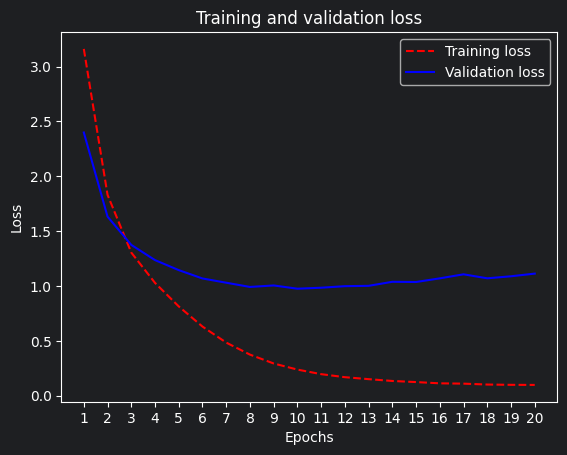

In [107]:
# print loss
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.savefig("reuters_loss_plot.png", dpi=300)

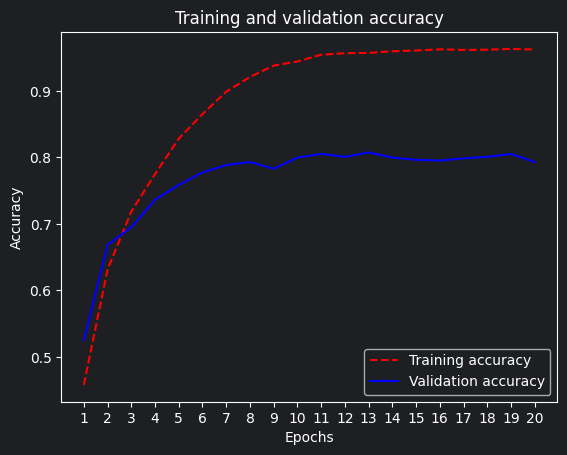

In [99]:
# print accuracy
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("reuters_accuracy_plot.png", dpi=300)

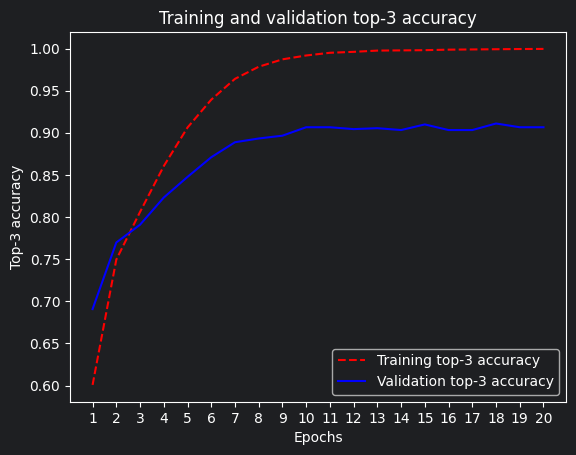

In [100]:
# print top-3-accuracy
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.savefig("reuters_top_3_accuracy_plot.png", dpi=300)

In [110]:
# SInce model was overfitting after 9 epochs -> new training with 9 epochs
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.fit(x_train,
          y_train,
          epochs=9,
          batch_size=32)
results = model.evaluate(x_test, y_test)

Epoch 1/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6760 - loss: 1.4963
Epoch 2/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8609 - loss: 0.6203
Epoch 3/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9264 - loss: 0.3266
Epoch 4/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9454 - loss: 0.2375
Epoch 5/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9483 - loss: 0.1888
Epoch 6/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9492 - loss: 0.1709
Epoch 7/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9515 - loss: 0.1535
Epoch 8/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9516 - loss: 0.1418
Epoch 9/9
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9542 - loss: 0.1297
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7850 - loss: 1.1544


In [102]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Epoch 1/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5383 - loss: 2.2972 - val_accuracy: 0.6752 - val_loss: 1.4762
Epoch 2/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7480 - loss: 1.1231 - val_accuracy: 0.7330 - val_loss: 1.2025
Epoch 3/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8458 - loss: 0.7018 - val_accuracy: 0.7731 - val_loss: 1.0635
Epoch 4/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.4226 - val_accuracy: 0.7842 - val_loss: 1.1028
Epoch 5/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9358 - loss: 0.2954 - val_accuracy: 0.7931 - val_loss: 1.1026
Epoch 6/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9522 - loss: 0.2149 - val_accuracy: 0.7853 - val_loss: 1.1209
Epoch 7/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9548 - loss: 0.1836 - val_accuracy: 0.7753 - val_loss: 1.1732
Epoch 8/9
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9567 - loss: 0.1626 - val_accuracy: 0.7831 - val_loss: 1.1567


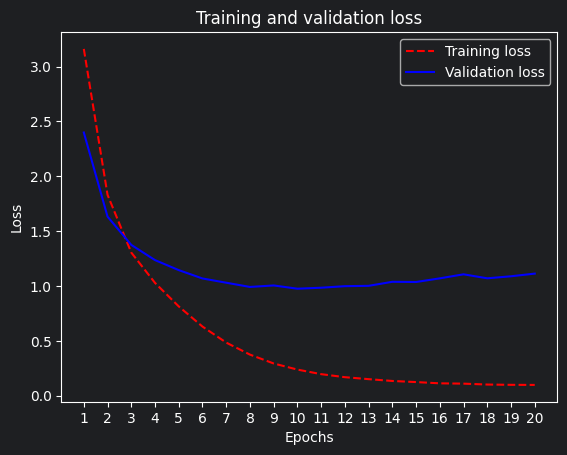

In [114]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.fit(x_train,
          y_train,
          epochs=9,
          batch_size=128,
          validation_split=0.1)

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.savefig("reuters_loss_plot.png", dpi=300)